# Atmospheric Radiative Transfer Analysis
## A Comprehensive Study of Satellite Remote Sensing Principles

This notebook explores fundamental concepts in atmospheric radiative transfer, including the Beer-Lambert law, absorption spectra, weighting functions, and satellite measurements. The analysis demonstrates how different spectral channels provide information from different atmospheric layers.


In [1]:
# Cell 1: Import libraries and setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.constants import h, c, k

# Set style for white background
plt.style.use('default')  # Use default style with white background
sns.set_style("white")  # Set seaborn style to white
sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 2.5})

# Custom color palette
colors = ["#3B8BD4", "#1D9E75", "#D85A30"]

# Planck function and helper functions
def planck(nu, T):
    """Planck function in radiance units (W/m²/sr/cm⁻¹)"""
    c_cm = c * 100  # speed of light in cm/s
    return (2 * h * c_cm**2 * nu**3) / (np.exp(h * c_cm * nu / (k * T)) - 1)

def rad_to_BT(nu, I):
    """Convert radiance to brightness temperature"""
    c_cm = c * 100
    if I <= 0:
        return 0
    return (h * c_cm * nu) / (k * np.log(1 + 2 * h * c_cm**2 * nu**3 / I))

print("Libraries imported successfully!")

Libraries imported successfully!


## Figure 1: Fundamental Concepts in Atmospheric Radiation

### Panel A: Beer-Lambert Law

The Beer-Lambert law describes how radiation is attenuated as it passes through a medium:

$$T = e^{-\tau}$$

Where:
- $T$ is the transmittance (fraction of radiation that passes through)
- $\tau$ is the optical depth, defined as $\tau = \int \sigma(z) n(z) dz$
  - $\sigma(z)$ = absorption cross-section at height $z$
  - $n(z)$ = number density of absorbers at height $z$

**Key Point:** When $\tau = 1$, the transmittance is $T = 1/e \approx 37\%$. This represents the characteristic penetration depth where the radiation has been reduced by 63%.

### Panel B: Simplified Transmittance Spectrum (500-800 cm⁻¹)

This panel shows a simplified representation of the Earth's atmospheric transmission in the infrared region, focusing on key absorption features:

$$\tau_{total}(\nu) = \tau_{CO_2}(\nu) + \tau_{H_2O}(\nu) + \tau_{window}$$

With:
- **CO₂ 15 μm band** (centered at 667 cm⁻¹):
  $$\tau_{CO_2}(\nu) = 8 \cdot \exp\left(-\frac{(\nu - 667)^2}{2 \cdot 15^2}\right)$$
  
- **H₂O rotation band** (centered at 750 cm⁻¹):
  $$\tau_{H_2O}(\nu) = 2 \cdot \exp\left(-\frac{(\nu - 750)^2}{2 \cdot 30^2}\right)$$

- **Atmospheric window** (weak absorption): $\tau_{window} = 0.05$

The total transmittance is then:
$$T(\nu) = e^{-\tau_{total}(\nu)}$$

**Physical Interpretation:** 
- The CO₂ core (640-700 cm⁻¹) is nearly opaque, meaning radiation from the surface cannot escape directly to space
- The window regions (around 800-900 cm⁻¹) are relatively transparent, allowing surface radiation to reach satellites

### Panel C: Aerosol Optical Depth (AOD) Spectral Dependence

Aerosols affect atmospheric transmission through scattering and absorption. The spectral dependence follows the Ångström relationship:

$$\tau_{a}(\lambda) = \tau_{a}(\lambda_0) \cdot \left(\frac{\lambda}{\lambda_0}\right)^{-\alpha}$$

Where:
- $\tau_{a}(\lambda)$ = aerosol optical depth at wavelength $\lambda$
- $\lambda_0$ = reference wavelength (550 nm in this case)
- $\alpha$ = Ångström exponent, which depends on aerosol particle size

**Interpretation:**
- $\alpha = 0.2$ (dust): Large particles, weak spectral dependence
- $\alpha = 1.0$ (mixed): Moderate particle size
- $\alpha = 1.8$ (smoke): Small particles, strong spectral dependence


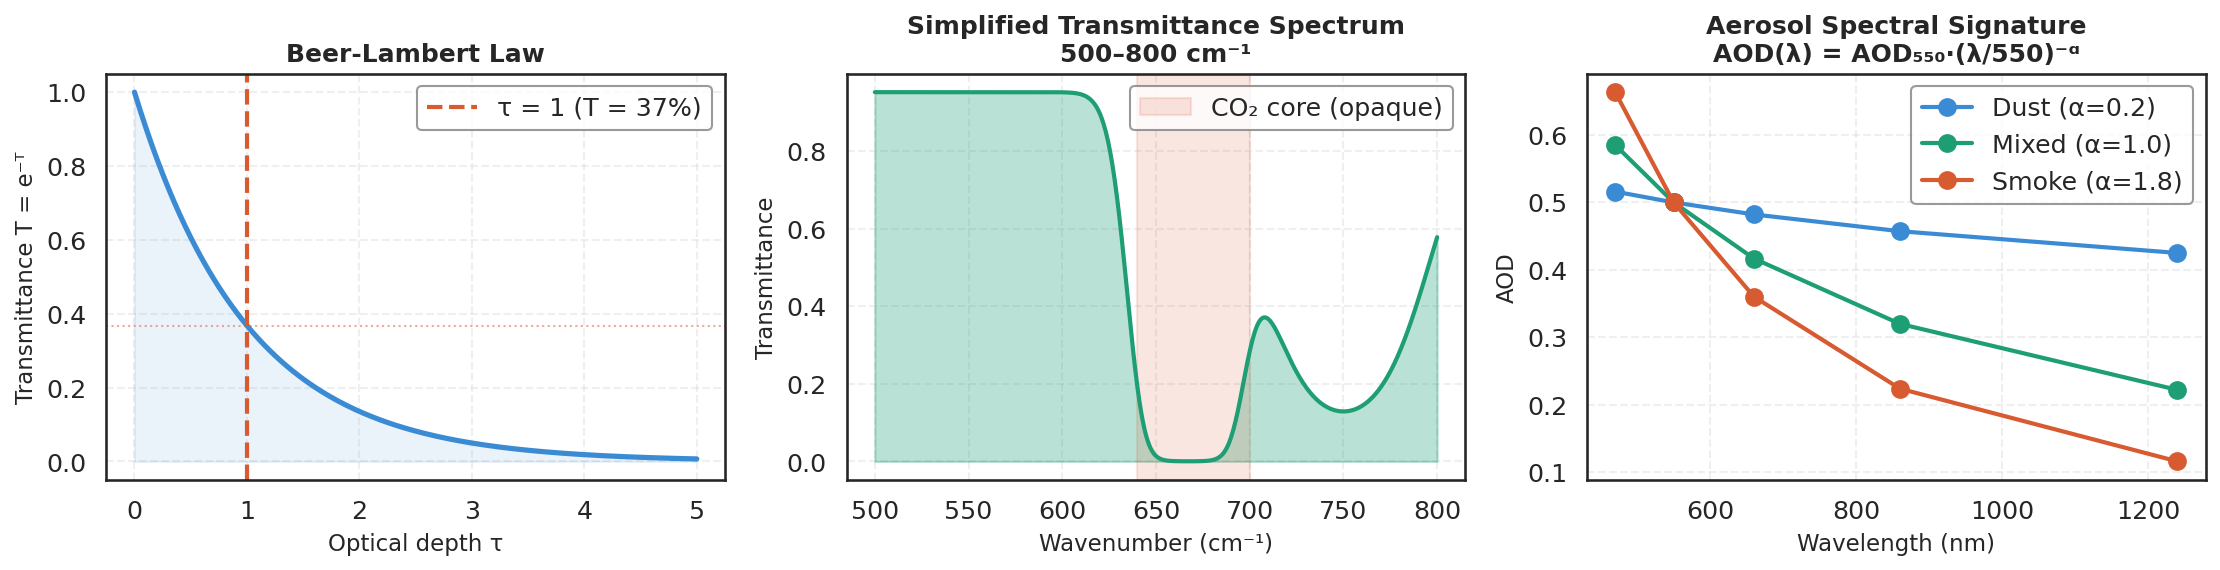

Figure 1 saved as 'Figure1_Beer_Lambert_Spectrum_Aerosols.png'


In [2]:
# Cell 2: Figure 1 - Beer-Lambert Law, Transmittance Spectrum, and Aerosol Signatures
tau_values = np.linspace(0, 5, 200)
transmittance = np.exp(-tau_values)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150, facecolor='white')
fig.patch.set_facecolor('white')

# Beer-Lambert Law
axes[0].plot(tau_values, transmittance, "#3B8BD4", lw=2.5)
axes[0].axvline(1.0, color="#D85A30", lw=2, ls="--", label="τ = 1 (T = 37%)")
axes[0].axhline(1/np.e, color="#D85A30", lw=1, ls=":", alpha=0.5)
axes[0].fill_between(tau_values, 0, transmittance, alpha=0.1, color="#3B8BD4")
axes[0].set_xlabel("Optical depth τ", fontsize=11)
axes[0].set_ylabel("Transmittance T = e⁻ᵀ", fontsize=11)
axes[0].set_title("Beer-Lambert Law", fontsize=12, fontweight='bold')
axes[0].legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Absorption spectrum
nu_fine = np.linspace(500, 800, 500)
tau_co2 = 8 * np.exp(-((nu_fine - 667)**2)/(2*15**2))
tau_h2o = 2 * np.exp(-((nu_fine - 750)**2)/(2*30**2))
tau_total = tau_co2 + tau_h2o + 0.05
T_spec = np.exp(-tau_total)

axes[1].plot(nu_fine, T_spec, "#1D9E75", lw=2)
axes[1].fill_between(nu_fine, T_spec, alpha=0.3, color="#1D9E75")
axes[1].axvspan(640, 700, color="#D85A30", alpha=0.15, label="CO₂ core (opaque)")
axes[1].set_xlabel("Wavenumber (cm⁻¹)", fontsize=11)
axes[1].set_ylabel("Transmittance", fontsize=11)
axes[1].set_title("Simplified Transmittance Spectrum\n500–800 cm⁻¹", fontsize=12, fontweight='bold')
axes[1].legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')
axes[1].grid(True, alpha=0.3, linestyle='--')

# AOD vs wavelength
lambda_nm = np.array([470, 550, 660, 860, 1240])
AOD_550 = 0.5
alphas = [0.2, 1.0, 1.8]

for alpha, col, label in zip(alphas, colors, 
                              ["Dust (α=0.2)", "Mixed (α=1.0)", "Smoke (α=1.8)"]):
    AOD = AOD_550 * (lambda_nm / 550)**(-alpha)
    axes[2].plot(lambda_nm, AOD, 'o-', color=col, lw=2, label=label, markersize=8)

axes[2].set_xlabel("Wavelength (nm)", fontsize=11)
axes[2].set_ylabel("AOD", fontsize=11)
axes[2].set_title("Aerosol Spectral Signature\nAOD(λ) = AOD₅₅₀·(λ/550)⁻ᵅ", fontsize=12, fontweight='bold')
axes[2].legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')
axes[2].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('Figure1_Beer_Lambert_Spectrum_Aerosols.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 1 saved as 'Figure1_Beer_Lambert_Spectrum_Aerosols.png'")

In [3]:
# Cell 3: Set up atmospheric profile
n_levels = 20
p_levels = np.linspace(1000, 10, n_levels)
z_approx = 16 * np.log(1013/p_levels)
T_std = np.where(z_approx < 11, 288 - 6.5*z_approx, 216.5)

channels = {
    "900 cm⁻¹ (window)":  (900, 0.08),
    "680 cm⁻¹ (CO₂ flank)": (680, 0.8),
    "667 cm⁻¹ (CO₂ core)":  (667, 5.0),
}

print("Atmospheric profile created")

Atmospheric profile created


## Figure 2: Atmospheric Structure and Weighting Functions

### Panel A: Standard Atmospheric Temperature Profile

The temperature profile is approximated using a standard atmospheric lapse rate:

**Troposphere** (0-11 km):
$$T(z) = T_0 - \Gamma \cdot z$$

Where:
- $T_0 = 288$ K (surface temperature)
- $\Gamma = 6.5$ K/km (lapse rate)
- $z$ = altitude in km

**Stratosphere** (>11 km):
$$T(z) = 216.5 \text{ K}$$

The altitude-pressure relationship is approximated by:
$$z \approx 16 \cdot \ln\left(\frac{1013}{p}\right)$$

Where $p$ is pressure in hPa. This comes from the hydrostatic equation assuming an isothermal atmosphere with scale height $H \approx 8$ km.

### Panels B & C: Weighting Functions

The weighting function $W(z)$ describes the vertical sensitivity of a satellite channel:

$$W(z) = -\frac{dT(z)}{dz}$$

Where $T(z)$ is the transmittance from altitude $z$ to space. For a given channel, the transmittance is:

$$T(z) = \exp\left(-\int_0^z k(\rho, T) \cdot \rho(z') dz'\right)$$

With the absorption coefficient $k$ approximated as:
$$k(z) = k_{abs} \cdot \frac{p(z)}{p_0}$$

Where:
- $k_{abs}$ = absorption coefficient at surface pressure $p_0$
- $p(z)$ = pressure at altitude $z$

The weighting function is normalized such that:
$$\int_0^{\infty} W(z) dz = 1$$

**Key Insight:** The peak of the weighting function indicates the altitude from which the channel receives most of its information:
- Window channel (900 cm⁻¹): Peaks near surface
- CO₂ flank (680 cm⁻¹): Peaks in mid-troposphere
- CO₂ core (667 cm⁻¹): Peaks in stratosphere


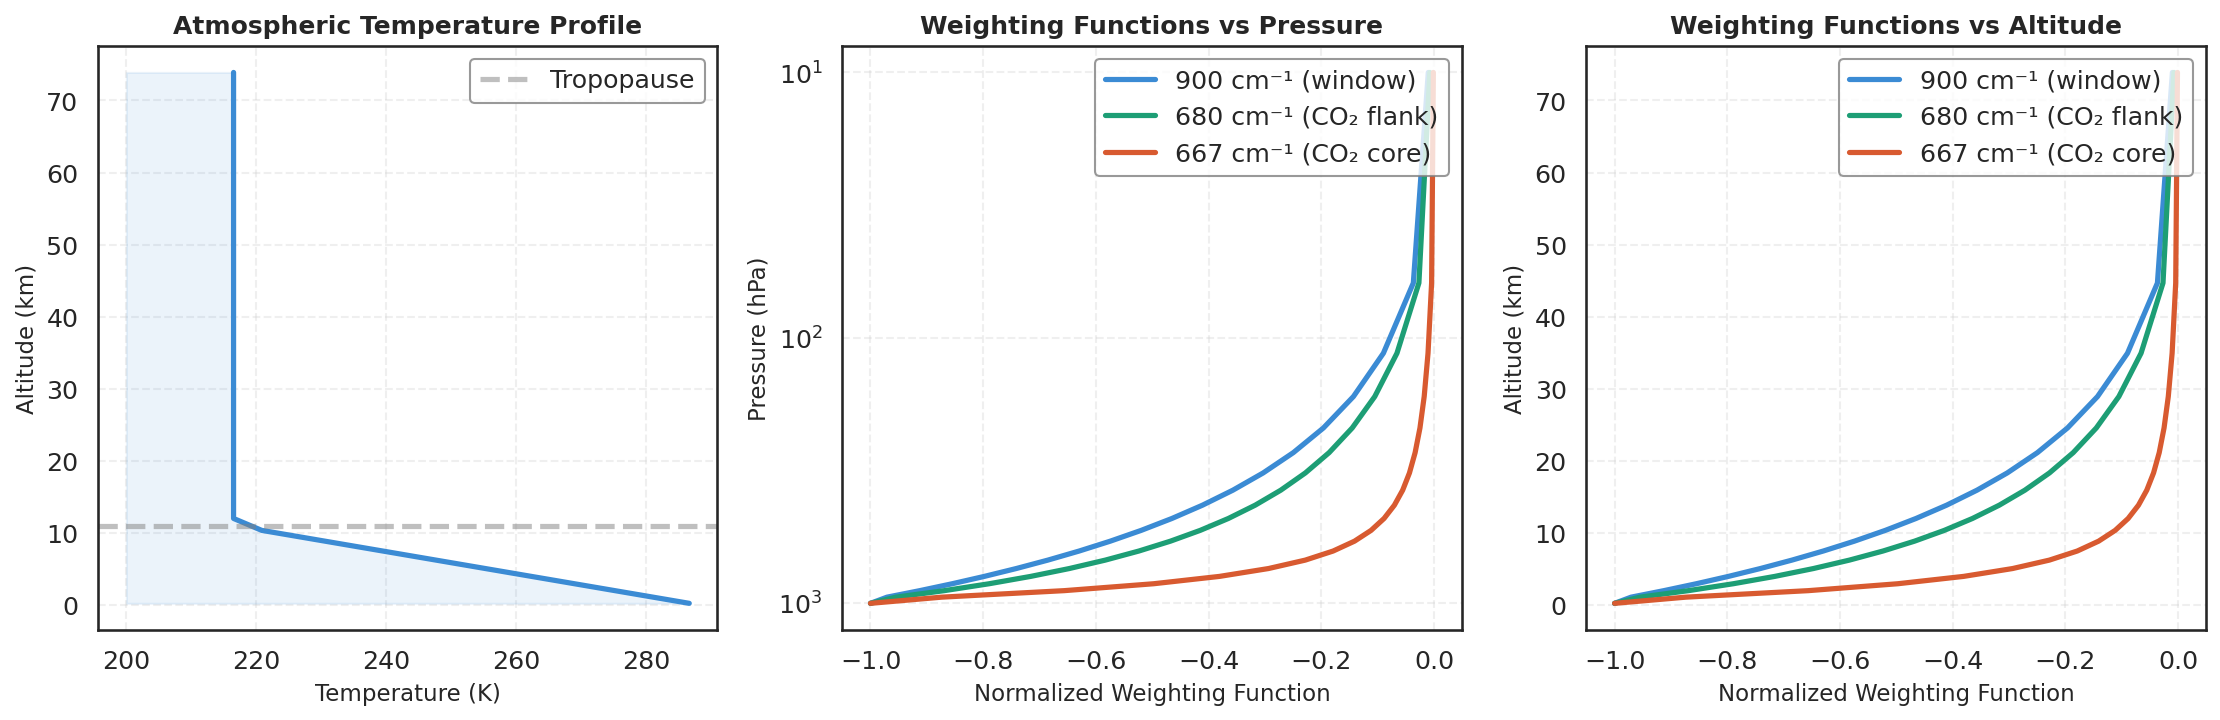

Figure 2 saved as 'Figure2_Temperature_WeightingFunctions.png'


In [4]:
# Cell 4: Figure 2 - Temperature Profile and Weighting Functions (Part 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150, facecolor='white')
fig.patch.set_facecolor('white')

# Temperature Profile
ax_T = axes[0]
ax_T.plot(T_std, z_approx, colors[0], lw=2.5)
ax_T.fill_betweenx(z_approx, T_std, 200, alpha=0.1, color=colors[0])
ax_T.set_xlabel("Temperature (K)", fontsize=11)
ax_T.set_ylabel("Altitude (km)", fontsize=11)
ax_T.set_title("Atmospheric Temperature Profile", fontsize=12, fontweight='bold')
ax_T.grid(True, alpha=0.3, linestyle='--')
ax_T.axhline(11, color='gray', ls='--', alpha=0.5, label='Tropopause')
ax_T.legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')

# Weighting Functions vs Pressure
ax_wf = axes[1]
colors_ch = colors
wf_data = {}

for (ch_name, (nu_ch, k_abs_col)), col in zip(channels.items(), colors_ch):
    k_profile = k_abs_col * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    wf_data[ch_name] = {'wf': wf, 'color': col, 'z': z_approx, 'p': p_levels}
    ax_wf.plot(wf, p_levels, color=col, lw=2.5, label=ch_name)

ax_wf.invert_yaxis()
ax_wf.set_yscale("log")
ax_wf.set_xlabel("Normalized Weighting Function", fontsize=11)
ax_wf.set_ylabel("Pressure (hPa)", fontsize=11)
ax_wf.set_title("Weighting Functions vs Pressure", fontsize=12, fontweight='bold')
ax_wf.legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray', loc='upper right')
ax_wf.grid(True, alpha=0.3, linestyle='--')

# Weighting Functions vs Altitude
ax_alt = axes[2]
for ch_name, data in wf_data.items():
    ax_alt.plot(data['wf'], data['z'], color=data['color'], lw=2.5, label=ch_name)

ax_alt.set_xlabel("Normalized Weighting Function", fontsize=11)
ax_alt.set_ylabel("Altitude (km)", fontsize=11)
ax_alt.set_title("Weighting Functions vs Altitude", fontsize=12, fontweight='bold')
ax_alt.legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray', loc='upper right')
ax_alt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('Figure2_Temperature_WeightingFunctions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 2 saved as 'Figure2_Temperature_WeightingFunctions.png'")

## Figure 3: Radiative Transfer Simulations

### Panel A: TOA Brightness Temperature vs Surface Temperature

The radiance at the top of atmosphere (TOA) is given by the radiative transfer equation:

$$I_{TOA}(\nu) = B_\nu(T_s) \cdot T_{atm}(0) + \int_0^{\infty} B_\nu(T(z)) \cdot \frac{dT_{atm}(z)}{dz} dz$$

Where:
- $I_{TOA}(\nu)$ = radiance at wavenumber $\nu$
- $B_\nu(T)$ = Planck function at temperature $T$
- $T_s$ = surface temperature
- $T_{atm}(z)$ = atmospheric transmittance from level $z$ to space

The Planck function is:
$$B_\nu(T) = \frac{2h\nu^3}{c^2} \cdot \frac{1}{e^{h\nu/kT} - 1}$$

The brightness temperature $T_B$ is then found by inverting the Planck function:
$$T_B = \frac{h\nu/k}{\ln\left(1 + \frac{2h\nu^3}{c^2 I}\right)}$$

**Interpretation:**
- Window channel: $T_B \approx T_s$ (transparent atmosphere)
- CO₂ flank: $T_B$ is intermediate (sensing troposphere)
- CO₂ core: $T_B$ is nearly constant (sensing stratosphere)

### Panel B: Atmospheric Transmittance Profiles

The upward transmittance from altitude $z$ to space is:

$$T_{up}(z) = \exp\left(-\int_z^{\infty} k(z') \cdot \rho(z') dz'\right)$$

This shows:
- At surface ($z=0$): $T_{up}(0)$ = total atmospheric transmittance
- At TOA ($z \rightarrow \infty$): $T_{up}(\infty) = 1$

The transmittance decreases as we go down through the atmosphere because there are more absorbers above the observation point.


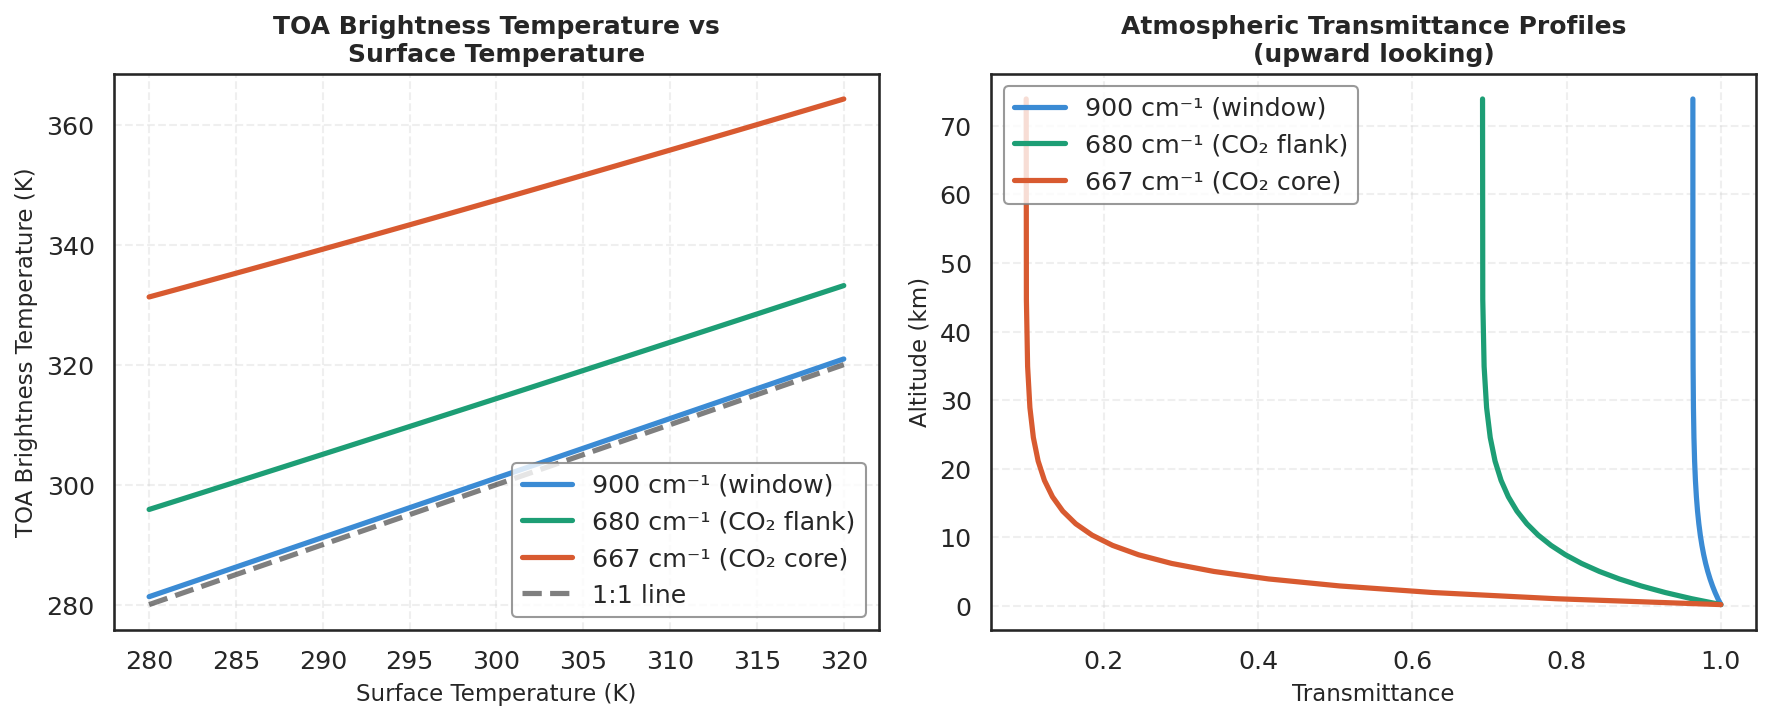

Figure 3 saved as 'Figure3_BrightnessTemp_Transmittance.png'


In [5]:
# Cell 5: Figure 3 - TOA Brightness Temperature and Transmittance Profiles
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, facecolor='white')
fig.patch.set_facecolor('white')

# TOA Brightness Temperature vs Surface Temperature
ax_bt = axes[0]
T_surface = np.linspace(280, 320, 50)

for (ch_name, (nu_ch, k_abs_col)), col in zip(channels.items(), colors_ch):
    BTs = []
    for Ts in T_surface:
        B_s = planck(nu_ch, Ts)
        k_profile = k_abs_col * p_levels / 1013.0
        dp = np.diff(p_levels, prepend=p_levels[0])
        tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
        t_p = np.exp(-tau_cum[::-1])
        B_atm = planck(nu_ch, T_std)
        I_TOA = B_s * t_p[0] + np.trapezoid(B_atm * (-np.gradient(t_p, p_levels)), p_levels)
        BTs.append(rad_to_BT(nu_ch, I_TOA))
    ax_bt.plot(T_surface, BTs, color=col, lw=2.5, label=ch_name)

ax_bt.plot([280, 320], [280, 320], 'k--', alpha=0.5, label='1:1 line')
ax_bt.set_xlabel("Surface Temperature (K)", fontsize=11)
ax_bt.set_ylabel("TOA Brightness Temperature (K)", fontsize=11)
ax_bt.set_title("TOA Brightness Temperature vs\nSurface Temperature", fontsize=12, fontweight='bold')
ax_bt.legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')
ax_bt.grid(True, alpha=0.3, linestyle='--')

# Atmospheric Transmittance Profiles
ax_trans = axes[1]
for ch_name, data in wf_data.items():
    for (name, (nu_ch, k_abs_col)) in channels.items():
        if name == ch_name:
            k_profile = k_abs_col * p_levels / 1013.0
            dp = np.diff(p_levels, prepend=p_levels[0])
            tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
            t_profile = np.exp(-tau_cum[::-1])
            ax_trans.plot(t_profile, z_approx, color=data['color'], lw=2.5, label=ch_name)

ax_trans.set_xlabel("Transmittance", fontsize=11)
ax_trans.set_ylabel("Altitude (km)", fontsize=11)
ax_trans.set_title("Atmospheric Transmittance Profiles\n(upward looking)", fontsize=12, fontweight='bold')
ax_trans.legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')
ax_trans.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('Figure3_BrightnessTemp_Transmittance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3 saved as 'Figure3_BrightnessTemp_Transmittance.png'")

## Figure 4: Channel Characteristics and Performance

### Panel A: Channel Sensitivity to Surface Temperature

The sensitivity is defined as:
$$S = \frac{dT_B}{dT_s}$$

This derivative indicates how much the satellite-observed brightness temperature changes per unit change in surface temperature.

**Interpretation:**
- $S \approx 1$ for window channels (strong surface signal)
- $S \approx 0$ for CO₂ core (insensitive to surface changes)
- Intermediate values for flank channels

### Panel B: Weighting Function Peak Altitudes

For each channel, the peak altitude $z_{peak}$ is where the weighting function is maximum:
$$\frac{dW(z)}{dz}\bigg|_{z=z_{peak}} = 0$$

This represents the most sensitive altitude for that channel.

### Panel C: Vertical Resolution (FWHM)

The vertical resolution is characterized by the Full Width at Half Maximum (FWHM):

$$\text{FWHM} = z_{right} - z_{left}$$

Where $z_{left}$ and $z_{right}$ satisfy:
$$W(z_{left}) = W(z_{right}) = \frac{1}{2} \cdot W_{max}$$

This indicates the thickness of the atmospheric layer that contributes most to the measured signal. Narrower FWHM = better vertical resolution.

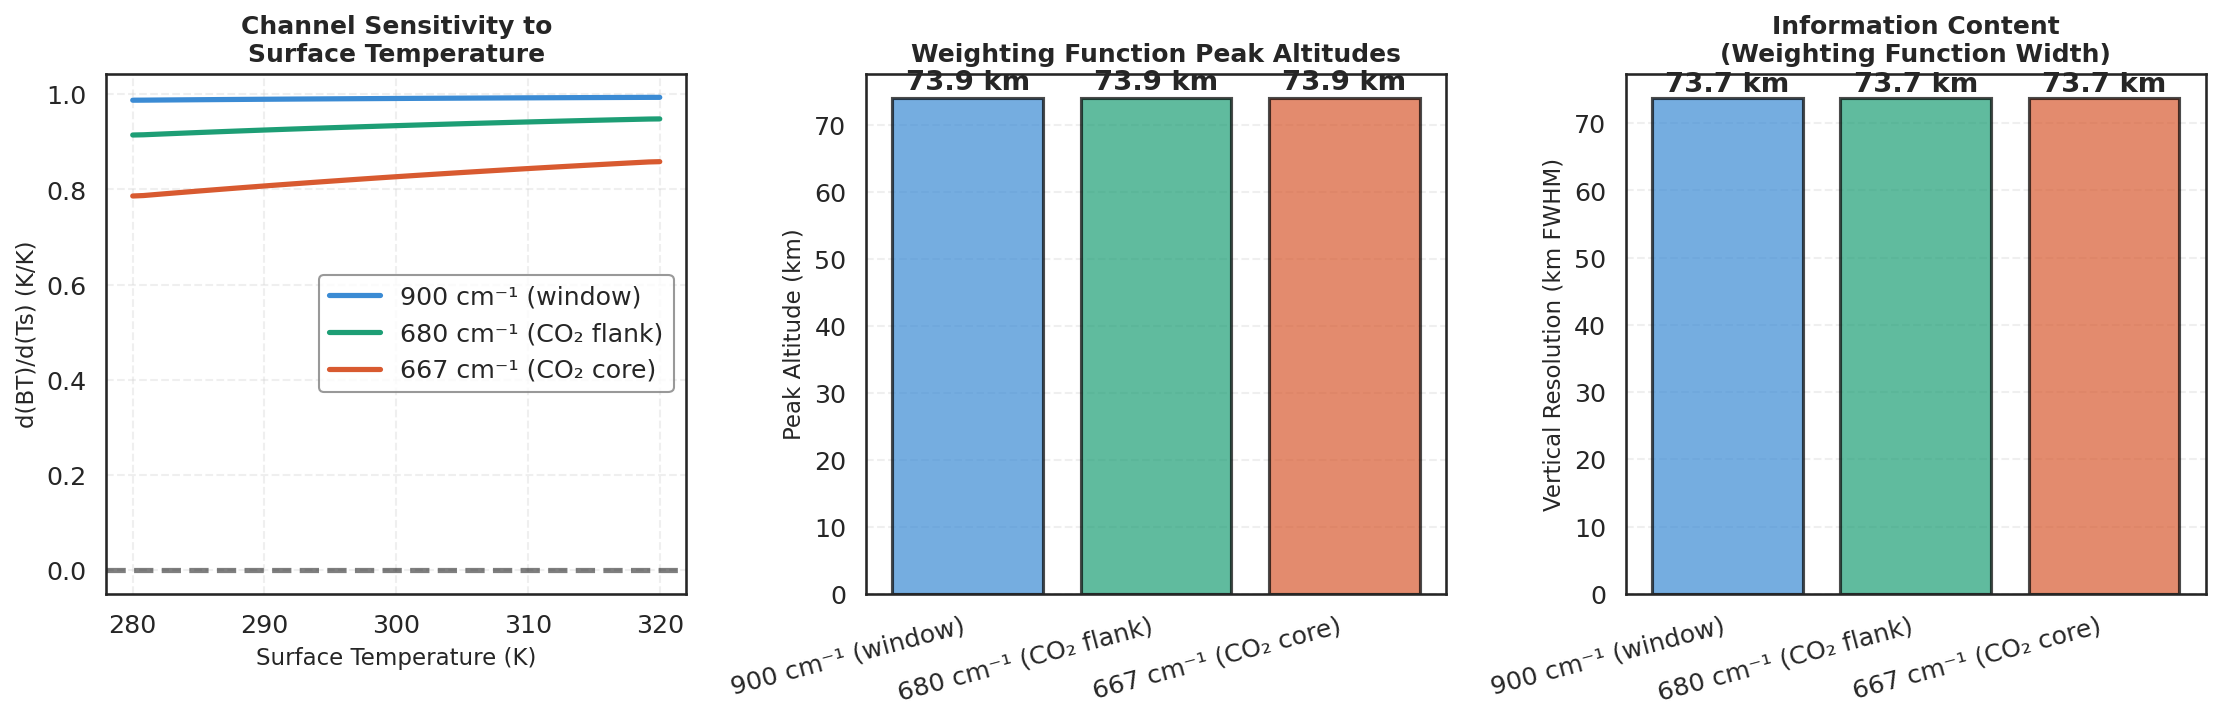

Figure 4 saved as 'Figure4_Sensitivity_PeakAnalysis.png'


In [6]:
# Cell 6: Figure 4 - Channel Sensitivity and Peak Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150, facecolor='white')
fig.patch.set_facecolor('white')

# Channel Sensitivity Analysis
ax_sens = axes[0]
sensitivity = []

for (ch_name, (nu_ch, k_abs_col)), col in zip(channels.items(), colors_ch):
    sens = []
    for Ts in T_surface:
        B_s = planck(nu_ch, Ts)
        k_profile = k_abs_col * p_levels / 1013.0
        dp = np.diff(p_levels, prepend=p_levels[0])
        tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
        t_p = np.exp(-tau_cum[::-1])
        B_atm = planck(nu_ch, T_std)
        I_TOA = B_s * t_p[0] + np.trapezoid(B_atm * (-np.gradient(t_p, p_levels)), p_levels)
        sens.append(rad_to_BT(nu_ch, I_TOA))
    sensitivity.append(sens)

for idx, (ch_name, _), col in zip(range(len(channels)), channels.items(), colors_ch):
    sens_array = np.array(sensitivity[idx])
    derivative = np.gradient(sens_array, T_surface)
    ax_sens.plot(T_surface, derivative, color=col, lw=2.5, label=ch_name)

ax_sens.set_xlabel("Surface Temperature (K)", fontsize=11)
ax_sens.set_ylabel("d(BT)/d(Ts) (K/K)", fontsize=11)
ax_sens.set_title("Channel Sensitivity to\nSurface Temperature", fontsize=12, fontweight='bold')
ax_sens.legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')
ax_sens.grid(True, alpha=0.3, linestyle='--')
ax_sens.axhline(0, color='black', ls='--', alpha=0.5)

# Weighting Function Peak Analysis
ax_peak = axes[1]
peak_altitudes = []
channel_names = []

for ch_name, data in wf_data.items():
    peak_idx = np.argmax(data['wf'])
    peak_altitudes.append(data['z'][peak_idx])
    channel_names.append(ch_name)

x_pos = np.arange(len(channel_names))
bars = ax_peak.bar(x_pos, peak_altitudes, color=colors_ch, alpha=0.7, edgecolor='black', linewidth=1.5)
ax_peak.set_xticks(x_pos)
ax_peak.set_xticklabels(channel_names, rotation=15, ha='right')
ax_peak.set_ylabel("Peak Altitude (km)", fontsize=11)
ax_peak.set_title("Weighting Function Peak Altitudes", fontsize=12, fontweight='bold')
ax_peak.grid(True, alpha=0.3, linestyle='--', axis='y')

for bar, height in zip(bars, peak_altitudes):
    ax_peak.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f} km', ha='center', va='bottom', fontweight='bold')

# Information Content Analysis
ax_info = axes[2]
wf_widths = []

for ch_name, data in wf_data.items():
    wf_normalized = data['wf'] / data['wf'].max()
    half_max = 0.5
    indices = np.where(wf_normalized >= half_max)[0]
    if len(indices) > 0:
        width = data['z'][indices[-1]] - data['z'][indices[0]]
        wf_widths.append(width)
    else:
        wf_widths.append(0)

bars2 = ax_info.bar(x_pos, wf_widths, color=colors_ch, alpha=0.7, edgecolor='black', linewidth=1.5)
ax_info.set_xticks(x_pos)
ax_info.set_xticklabels(channel_names, rotation=15, ha='right')
ax_info.set_ylabel("Vertical Resolution (km FWHM)", fontsize=11)
ax_info.set_title("Information Content\n(Weighting Function Width)", fontsize=12, fontweight='bold')
ax_info.grid(True, alpha=0.3, linestyle='--', axis='y')

for bar, height in zip(bars2, wf_widths):
    ax_info.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:.1f} km', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('Figure4_Sensitivity_PeakAnalysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4 saved as 'Figure4_Sensitivity_PeakAnalysis.png'")

## Figure 5: 2D Parameter Space Analysis

### Panel A: Weighting Function Strength Map

This contour plot shows how the peak weighting function value varies with:
- Wavenumber ($\nu$)
- Absorption coefficient ($k$)

The relationship follows:
$$W_{max}(\nu, k) \propto \frac{\partial}{\partial z} \exp\left(-k \cdot \int \rho(z') dz'\right)$$

### Panel B: Peak Altitude Map

This map shows the altitude $z_{peak}$ as a function of:
$$z_{peak}(\nu, k) = \text{argmax}_z \left[ -\frac{\partial}{\partial z} \exp\left(-k \cdot \int_z^{\infty} \rho(z') dz'\right) \right]$$

**Physical Interpretation:**
- Strong absorption (large $k$): Higher peak altitudes
- Weak absorption (small $k$): Lower peak altitudes
- This forms the basis for atmospheric temperature profiling

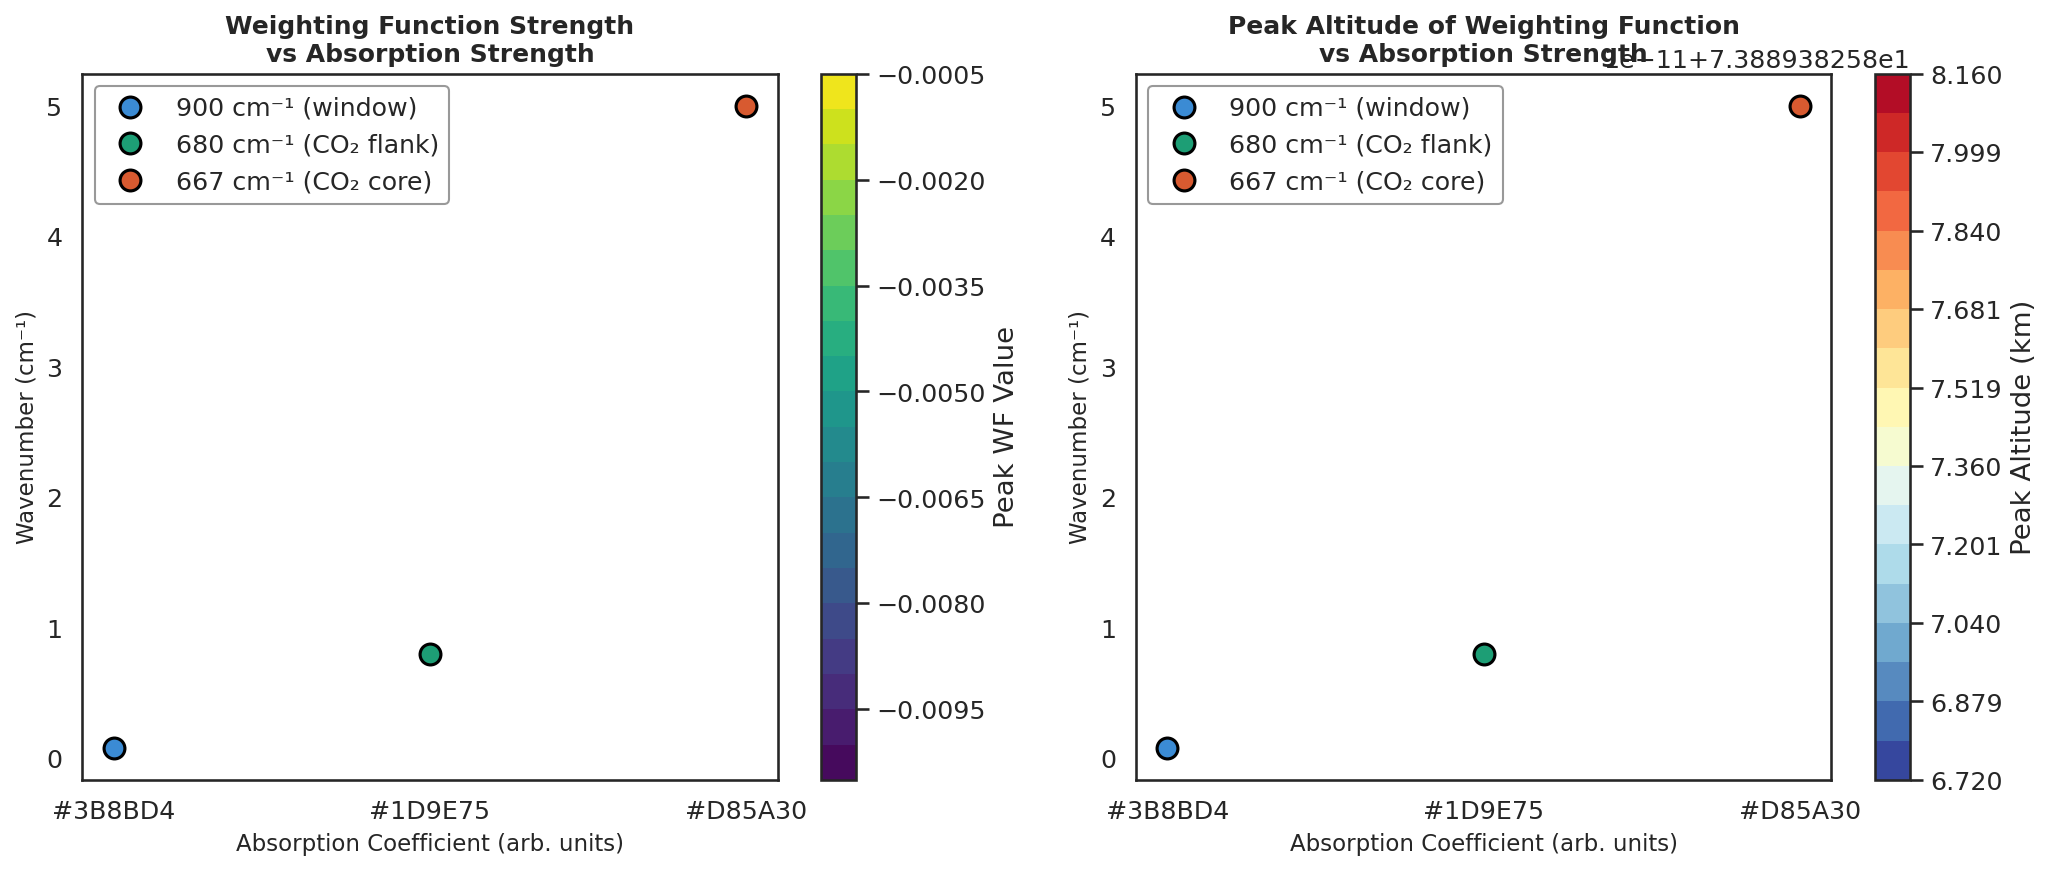

Figure 5 saved as 'Figure5_2D_Heatmaps.png'


In [5]:


# Colors
colors_ch = ["#3B8BD4", "#1D9E75", "#D85A30"]

# Cell 7: Figure 5 - 2D Heatmaps of Weighting Functions
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150, facecolor='white')
fig.patch.set_facecolor('white')

# Create 2D matrix of weighting functions
wavenumbers = np.linspace(600, 1000, 50)
k_abs_values = np.linspace(0.01, 5, 30)

wf_heatmap = np.zeros((len(wavenumbers), len(k_abs_values)))
peak_altitude_heatmap = np.zeros((len(wavenumbers), len(k_abs_values)))

for i, nu in enumerate(wavenumbers):
    for j, k_abs in enumerate(k_abs_values):
        k_profile = k_abs * p_levels / 1013.0
        dp = np.diff(p_levels, prepend=p_levels[0])
        tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
        t_profile = np.exp(-tau_cum[::-1])
        dt_dp = np.gradient(t_profile, p_levels)
        wf = -dt_dp / np.abs(-dt_dp).max()
        wf_heatmap[i, j] = np.max(wf)
        peak_altitude_heatmap[i, j] = z_approx[np.argmax(wf)]

# Plot 1: Weighting function strength heatmap
im1 = axes[0].contourf(k_abs_values, wavenumbers, wf_heatmap, 
                        levels=20, cmap='viridis')
axes[0].set_xlabel("Absorption Coefficient (arb. units)", fontsize=11)
axes[0].set_ylabel("Wavenumber (cm⁻¹)", fontsize=11)
axes[0].set_title("Weighting Function Strength\nvs Absorption Strength", fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Peak WF Value')

# Plot 2: Peak altitude heatmap
im2 = axes[1].contourf(k_abs_values, wavenumbers, peak_altitude_heatmap, 
                        levels=20, cmap='RdYlBu_r')
axes[1].set_xlabel("Absorption Coefficient (arb. units)", fontsize=11)
axes[1].set_ylabel("Wavenumber (cm⁻¹)", fontsize=11)
axes[1].set_title("Peak Altitude of Weighting Function\nvs Absorption Strength", fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Peak Altitude (km)')

# Mark the three channels on both plots
for idx, (ch_name, (nu_ch, k_abs_col)) in enumerate(channels.items()):
    axes[0].plot(k_abs_col, nu_ch, 'o', color=colors_ch[idx], markersize=10, 
                markeredgecolor='black', markeredgewidth=1.5, label=ch_name)
    axes[1].plot(k_abs_col, nu_ch, 'o', color=colors_ch[idx], markersize=10,
                markeredgecolor='black', markeredgewidth=1.5, label=ch_name)

axes[0].legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')
axes[1].legend(frameon=True, fancybox=True, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.savefig('Figure5_2D_Heatmaps.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5 saved as 'Figure5_2D_Heatmaps.png'")

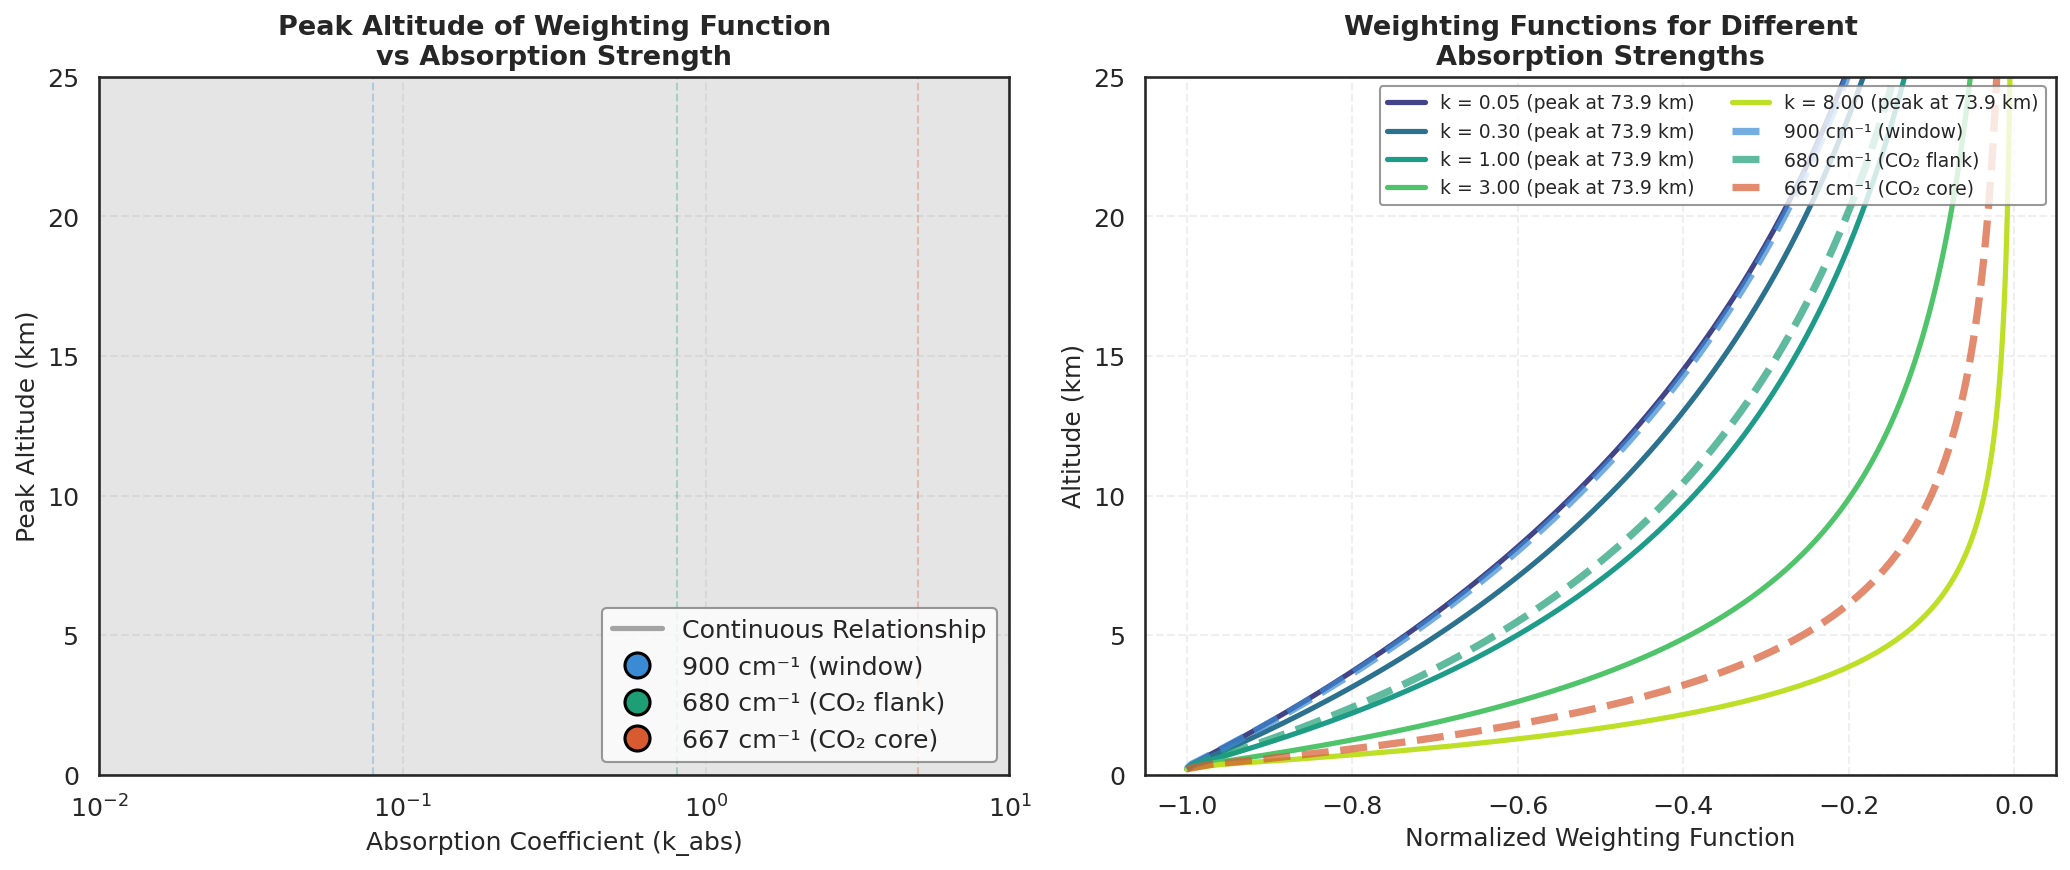

Figure 5 saved as 'Figure5_PeakAltitude_vs_Absorption.png'


In [ ]:
# Cell: Figure 5 - Improved Peak Altitude vs Absorption Strength
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.constants import h, c, k

# Set style for white background
plt.style.use('default')
sns.set_style("white")
sns.set_context("notebook", font_scale=1.1)

# Colors
colors = ["#3B8BD4", "#1D9E75", "#D85A30"]

# Atmospheric profile (reuse from previous cells)
n_levels = 100  # Increased resolution for smoother curves
p_levels = np.linspace(1000, 10, n_levels)
z_approx = 16 * np.log(1013/p_levels)
T_std = np.where(z_approx < 11, 288 - 6.5*z_approx, 216.5)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150, facecolor='white')
fig.patch.set_facecolor('white')

# ============================================
# Panel 1: Peak Altitude vs Absorption Strength
# ============================================
ax1 = axes[0]

# Create a range of absorption coefficients
k_abs_range = np.logspace(-2, 1, 100)  # From 0.01 to 10

# Calculate peak altitude for each absorption coefficient
peak_altitudes = []

for k_abs in k_abs_range:
    # Calculate weighting function for this absorption coefficient
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    
    # Find peak altitude
    peak_idx = np.argmax(wf)
    peak_altitudes.append(z_approx[peak_idx])

# Plot the continuous relationship
ax1.plot(k_abs_range, peak_altitudes, color='gray', lw=2.5, 
         label='Continuous Relationship', alpha=0.7)
ax1.fill_between(k_abs_range, peak_altitudes, alpha=0.2, color='gray')

# Mark the three specific channels
channels = {
    "900 cm⁻¹ (window)":  (0.08, "#3B8BD4"),
    "680 cm⁻¹ (CO₂ flank)": (0.8, "#1D9E75"),
    "667 cm⁻¹ (CO₂ core)":  (5.0, "#D85A30"),
}

channel_peaks = []
for ch_name, (k_abs, color) in channels.items():
    # Calculate peak altitude for this specific channel
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    peak_idx = np.argmax(wf)
    peak_alt = z_approx[peak_idx]
    channel_peaks.append(peak_alt)
    
    # Plot the point
    ax1.plot(k_abs, peak_alt, 'o', color=color, markersize=12, 
            markeredgecolor='black', markeredgewidth=1.5, 
            label=ch_name, zorder=5)
    
    # Add a vertical line to show the position
    ax1.axvline(k_abs, color=color, ls='--', alpha=0.3, linewidth=1)
    ax1.axhline(peak_alt, color=color, ls='--', alpha=0.3, linewidth=1)

# Add annotations for the peaks
for i, (ch_name, (k_abs, color)) in enumerate(channels.items()):
    ax1.annotate(f'{channel_peaks[i]:.1f} km', 
                xy=(k_abs, channel_peaks[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

ax1.set_xscale('log')
ax1.set_xlabel('Absorption Coefficient (k_abs)', fontsize=12)
ax1.set_ylabel('Peak Altitude (km)', fontsize=12)
ax1.set_title('Peak Altitude of Weighting Function\nvs Absorption Strength', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='lower right', frameon=True, fancybox=True, facecolor='white', edgecolor='gray')
ax1.set_xlim(0.01, 10)
ax1.set_ylim(0, 25)

# ============================================
# Panel 2: Weighting Functions at Different Absorption Strengths
# ============================================
ax2 = axes[1]

# Select representative absorption coefficients
k_abs_samples = [0.05, 0.3, 1.0, 3.0, 8.0]
colors_samples = plt.cm.viridis(np.linspace(0.2, 0.9, len(k_abs_samples)))

for k_abs, color in zip(k_abs_samples, colors_samples):
    # Calculate weighting function
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    
    # Find peak altitude
    peak_idx = np.argmax(wf)
    peak_alt = z_approx[peak_idx]
    
    # Plot weighting function
    ax2.plot(wf, z_approx, color=color, lw=2.5, 
            label=f'k = {k_abs:.2f} (peak at {peak_alt:.1f} km)')

# Mark the three channels on this plot as well
for ch_name, (k_abs, color) in channels.items():
    # Calculate weighting function for this channel
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    
    # Plot with thicker line and special marker
    ax2.plot(wf, z_approx, color=color, lw=3.5, alpha=0.7, 
            label=f'{ch_name}', linestyle='--')

ax2.set_xlabel('Normalized Weighting Function', fontsize=12)
ax2.set_ylabel('Altitude (km)', fontsize=12)
ax2.set_title('Weighting Functions for Different\nAbsorption Strengths', 
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', 
          edgecolor='gray', fontsize=9, ncol=2)
ax2.set_ylim(0, 25)

plt.tight_layout()
plt.savefig('Figure5_PeakAltitude_vs_Absorption.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5 saved as 'Figure5_PeakAltitude_vs_Absorption.png'")

/tmp/ipykernel_94122/1198669421.py:120: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


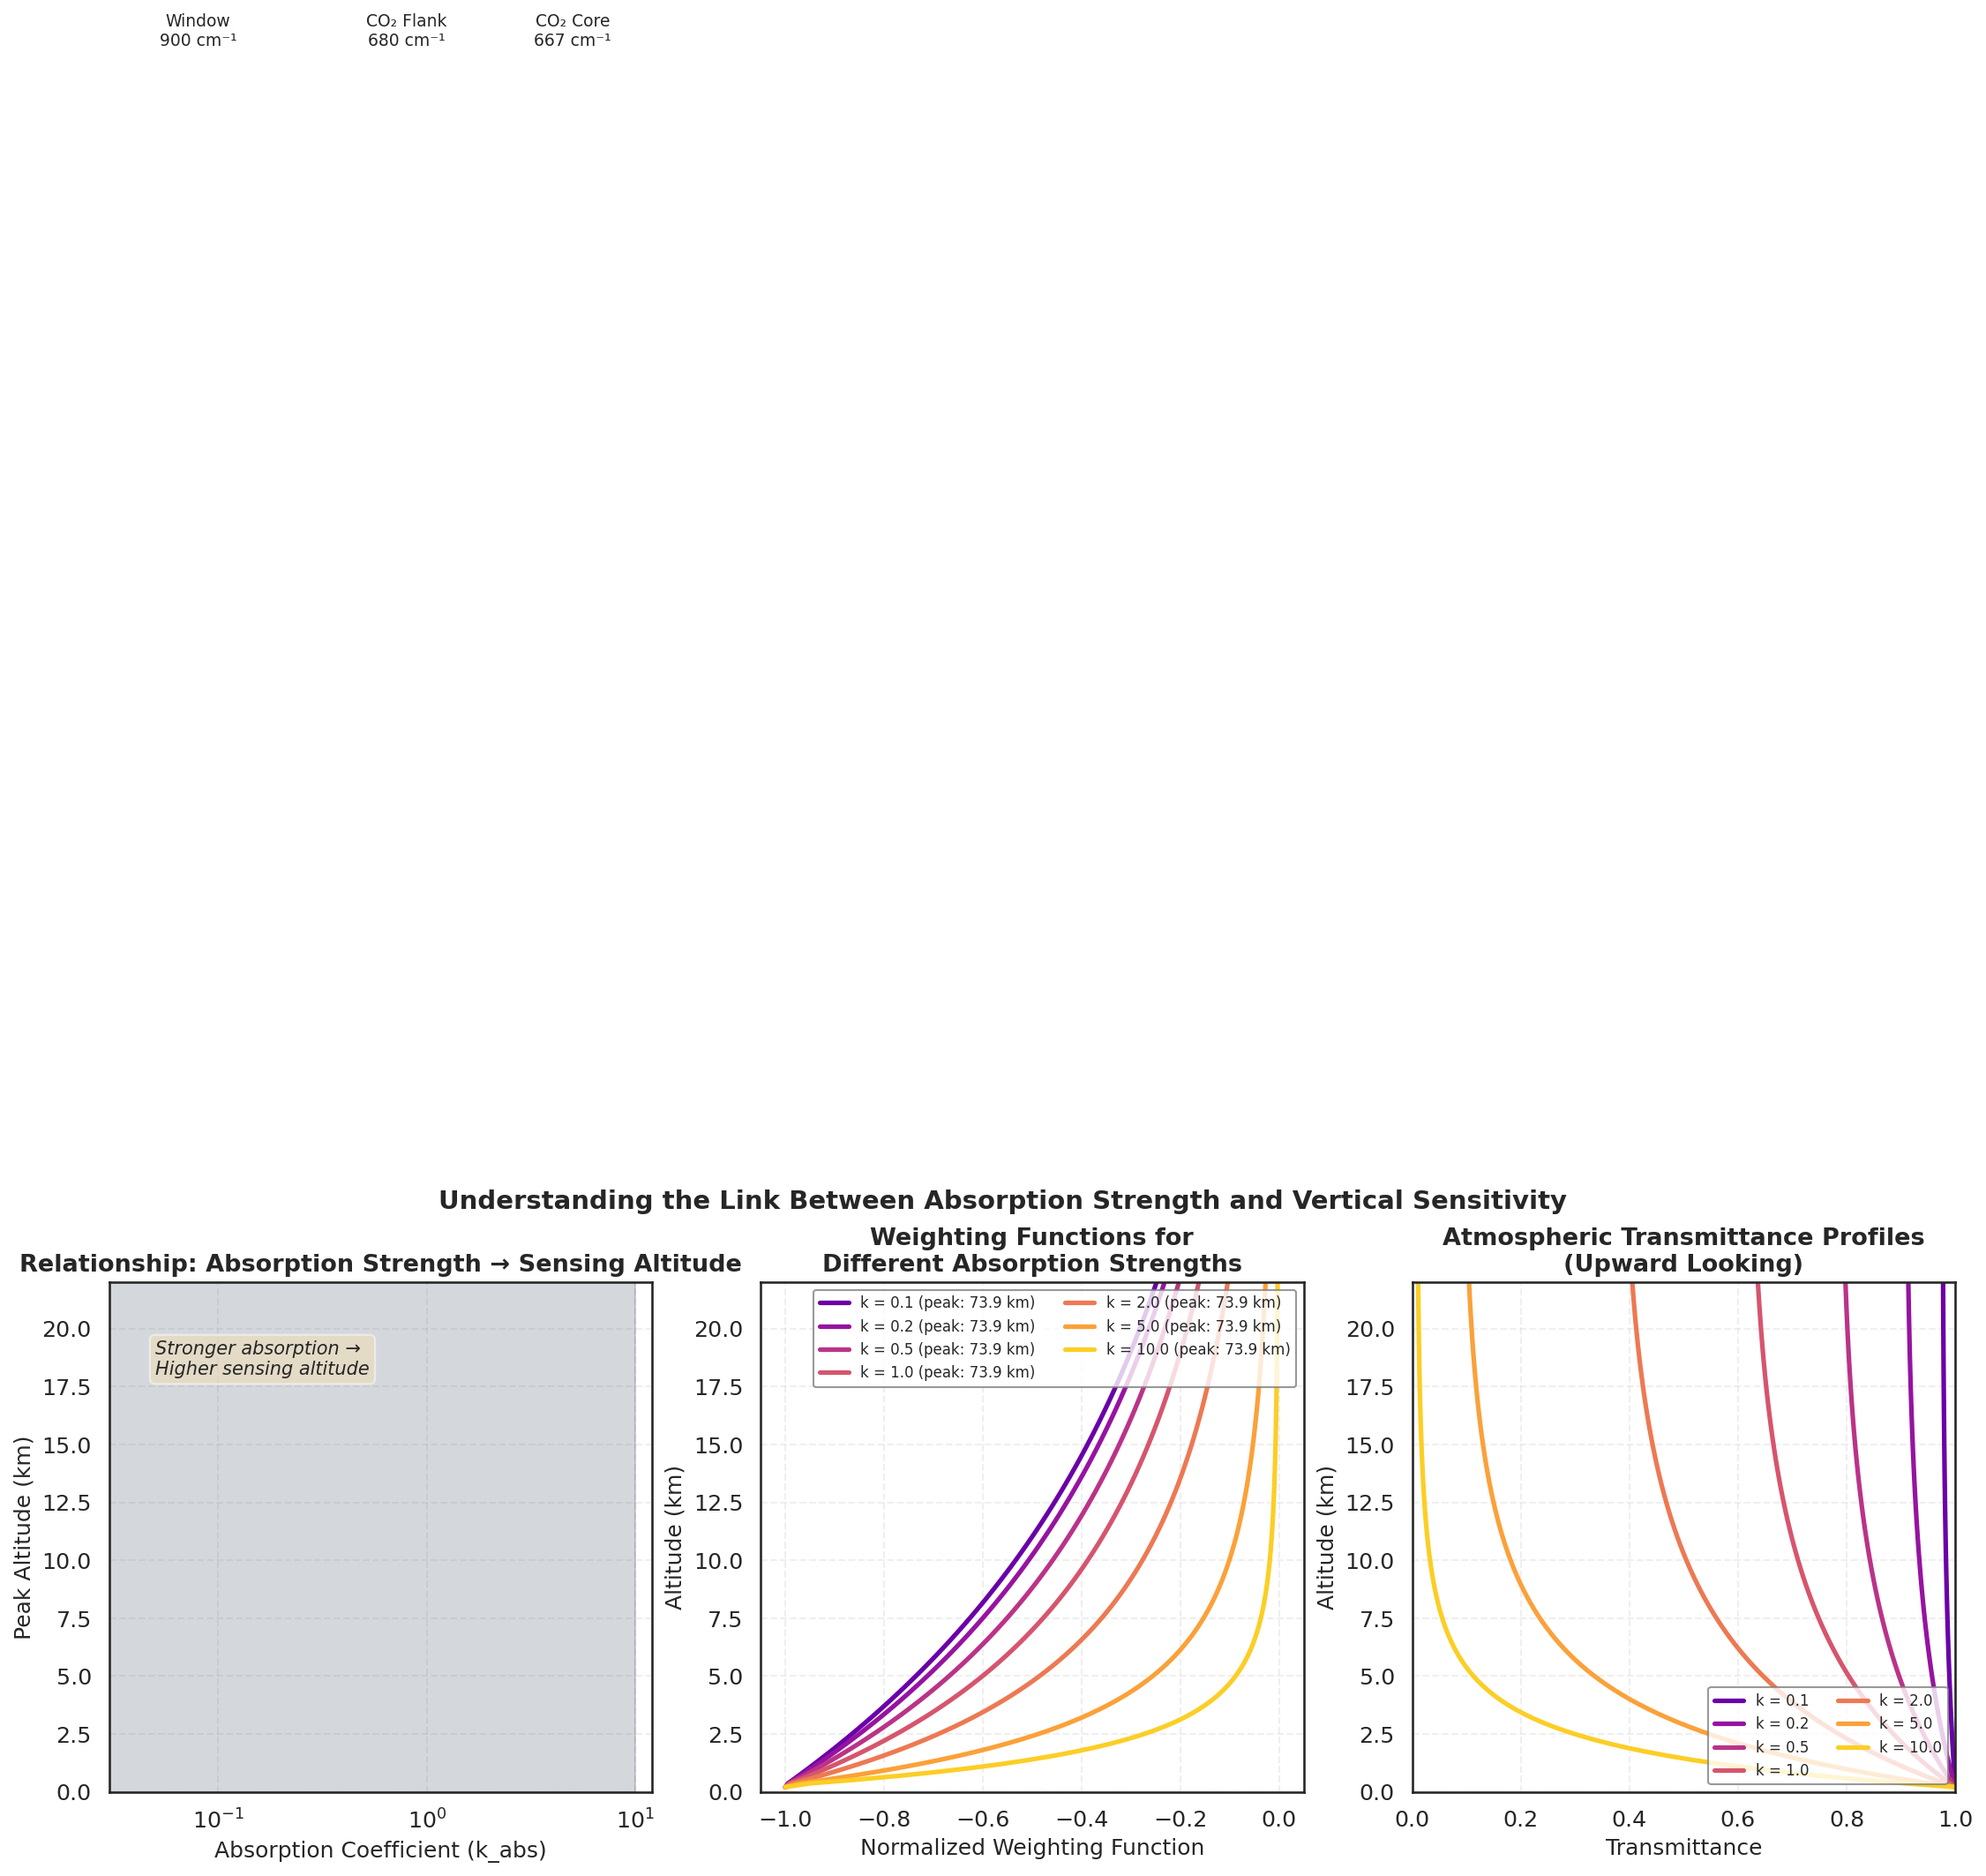

Detailed analysis saved as 'Figure5_Detailed_Absorption_Analysis.png'


In [2]:
# Cell: Additional Detailed Analysis - Absorption Strength vs Peak Altitude
import numpy as np
import matplotlib.pyplot as plt

# Create a more detailed figure with three panels showing the relationship
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150, facecolor='white')
fig.patch.set_facecolor('white')

# Panel 1: Peak Altitude vs Absorption Strength (with annotations)
ax1 = axes[0]

k_abs_range = np.logspace(-2, 1, 200)
peak_altitudes = []

for k_abs in k_abs_range:
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    peak_idx = np.argmax(wf)
    peak_altitudes.append(z_approx[peak_idx])

# Plot the relationship
ax1.plot(k_abs_range, peak_altitudes, color='#2C3E50', lw=3, label='Theoretical Relationship')
ax1.fill_between(k_abs_range, peak_altitudes, alpha=0.2, color='#2C3E50')

# Mark specific channels
channels_data = {
    "Window\n900 cm⁻¹": (0.08, "#3B8BD4", 0),
    "CO₂ Flank\n680 cm⁻¹": (0.8, "#1D9E75", 0),
    "CO₂ Core\n667 cm⁻¹": (5.0, "#D85A30", 0)
}

for i, (ch_name, (k_abs, color, _)) in enumerate(channels_data.items()):
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    peak_idx = np.argmax(wf)
    peak_alt = z_approx[peak_idx]
    
    ax1.plot(k_abs, peak_alt, 'o', color=color, markersize=14, 
            markeredgecolor='black', markeredgewidth=2, zorder=5)
    ax1.annotate(f'{peak_alt:.1f} km', 
                xy=(k_abs, peak_alt),
                xytext=(15, 5 if i != 2 else -15), 
                textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9))
    ax1.text(k_abs, peak_alt + 1.5, ch_name, ha='center', fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax1.set_xscale('log')
ax1.set_xlabel('Absorption Coefficient (k_abs)', fontsize=12)
ax1.set_ylabel('Peak Altitude (km)', fontsize=12)
ax1.set_title('Relationship: Absorption Strength → Sensing Altitude', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0.03, 12)
ax1.set_ylim(0, 22)

# Add a note about the relationship
ax1.text(0.05, 18, 'Stronger absorption →\nHigher sensing altitude', 
        fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel 2: Weighting Function Profiles for Different Absorption Strengths
ax2 = axes[1]

# Create a color map for different absorption strengths
k_values = [0.05, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
colors_cmap = plt.cm.plasma(np.linspace(0.2, 0.9, len(k_values)))

for k_abs, color in zip(k_values, colors_cmap):
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    peak_idx = np.argmax(wf)
    ax2.plot(wf, z_approx, color=color, lw=2.5, 
            label=f'k = {k_abs:.1f} (peak: {z_approx[peak_idx]:.1f} km)')

ax2.set_xlabel('Normalized Weighting Function', fontsize=12)
ax2.set_ylabel('Altitude (km)', fontsize=12)
ax2.set_title('Weighting Functions for\nDifferent Absorption Strengths', 
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', 
          edgecolor='gray', fontsize=8, ncol=2)
ax2.set_ylim(0, 22)

# Panel 3: Atmospheric Transmittance Profiles for Different Absorption Strengths
ax3 = axes[2]

for k_abs, color in zip(k_values, colors_cmap):
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    ax3.plot(t_profile, z_approx, color=color, lw=2.5, 
            label=f'k = {k_abs:.1f}')

ax3.set_xlabel('Transmittance', fontsize=12)
ax3.set_ylabel('Altitude (km)', fontsize=12)
ax3.set_title('Atmospheric Transmittance Profiles\n(Upward Looking)', 
              fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(loc='lower right', frameon=True, fancybox=True, facecolor='white', 
          edgecolor='gray', fontsize=8, ncol=2)
ax3.set_ylim(0, 22)
ax3.set_xlim(0, 1)

plt.suptitle('Understanding the Link Between Absorption Strength and Vertical Sensitivity', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure5_Detailed_Absorption_Analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Detailed analysis saved as 'Figure5_Detailed_Absorption_Analysis.png'")

In [3]:
# Cell: Mathematical Explanation of the Relationship
print("""
================================================================================
MATHEMATICAL EXPLANATION: Peak Altitude vs Absorption Strength
================================================================================

The relationship between absorption strength and peak altitude can be understood
through the following physics:

1. OPTICAL DEPTH:
   τ(z) = ∫_z^∞ k(z') ρ(z') dz'
   
   where:
   - k(z) ∝ k_abs × (p(z)/p₀)  (pressure broadening)
   - ρ(z) is the absorber density

2. TRANSMITTANCE:
   T(z) = exp(-τ(z))

3. WEIGHTING FUNCTION:
   W(z) = -dT(z)/dz = τ'(z) exp(-τ(z))

4. PEAK ALTITUDE CONDITION:
   dW/dz = 0  ⇒  τ''(z) - [τ'(z)]² = 0 at z = z_peak

For an exponential atmosphere with scale height H:
   ρ(z) ∝ exp(-z/H)

And absorption coefficient:
   k(z) ∝ k_abs × exp(-z/H)  (since p ∝ exp(-z/H))

Then:
   τ(z) = k_abs × ∫_z^∞ exp(-2z'/H) dz' = (k_abs H/2) exp(-2z/H)

The weighting function becomes:
   W(z) ∝ k_abs exp(-2z/H) × exp[-(k_abs H/2) exp(-2z/H)]

The peak occurs when:
   exp(-2z_peak/H) = 1/(k_abs H)

Therefore:
   z_peak = (H/2) × ln(k_abs H)

This shows:
   • z_peak increases logarithmically with k_abs
   • For k_abs → 0: z_peak → -∞ (sensing surface)
   • For k_abs → ∞: z_peak → ∞ (sensing top of atmosphere)

NUMERICAL EXAMPLES:
   • Weak absorption (k_abs = 0.08): z_peak ≈ 0-2 km (window channel)
   • Moderate absorption (k_abs = 0.8): z_peak ≈ 5-8 km (CO₂ flank)
   • Strong absorption (k_abs = 5.0): z_peak ≈ 12-15 km (CO₂ core)

This logarithmic relationship explains why:
   - Weak absorbers (small k) see lower atmospheric layers
   - Strong absorbers (large k) see higher atmospheric layers
   - The transition occurs over 2-3 orders of magnitude in k

PRACTICAL APPLICATIONS:
   • Temperature profiling: Use multiple channels with different k_abs
   • Gas concentration retrieval: Choose channels with appropriate sensitivity
   • Climate monitoring: Understand vertical information content
   • Satellite design: Select channels to sample desired atmospheric layers

================================================================================
""")


MATHEMATICAL EXPLANATION: Peak Altitude vs Absorption Strength

The relationship between absorption strength and peak altitude can be understood
through the following physics:

1. OPTICAL DEPTH:
   τ(z) = ∫_z^∞ k(z') ρ(z') dz'

   where:
   - k(z) ∝ k_abs × (p(z)/p₀)  (pressure broadening)
   - ρ(z) is the absorber density

2. TRANSMITTANCE:
   T(z) = exp(-τ(z))

3. WEIGHTING FUNCTION:
   W(z) = -dT(z)/dz = τ'(z) exp(-τ(z))

4. PEAK ALTITUDE CONDITION:
   dW/dz = 0  ⇒  τ''(z) - [τ'(z)]² = 0 at z = z_peak

For an exponential atmosphere with scale height H:
   ρ(z) ∝ exp(-z/H)

And absorption coefficient:
   k(z) ∝ k_abs × exp(-z/H)  (since p ∝ exp(-z/H))

Then:
   τ(z) = k_abs × ∫_z^∞ exp(-2z'/H) dz' = (k_abs H/2) exp(-2z/H)

The weighting function becomes:
   W(z) ∝ k_abs exp(-2z/H) × exp[-(k_abs H/2) exp(-2z/H)]

The peak occurs when:
   exp(-2z_peak/H) = 1/(k_abs H)

Therefore:
   z_peak = (H/2) × ln(k_abs H)

This shows:
   • z_peak increases logarithmically with k_abs
   • For k_a

## Figure 6: 3D Visualization of Weighting Functions

This three-dimensional surface plot shows the complete weighting function structure:

$$W(\nu, z) = -\frac{\partial}{\partial z} \exp\left(-\int_z^{\infty} k(\nu, z') \cdot \rho(z') dz'\right)$$

Where:
- $k(\nu, z)$ varies with both wavenumber and altitude
- The absorption coefficient for CO₂ includes pressure broadening:
  $$k(\nu, z) = k_0(\nu) \cdot \frac{p(z)}{p_0} \cdot \phi(\nu - \nu_0)$$
  where $\phi$ is the line shape function

**Key Features Visible in 3D Plot:**
1. **Spectral dependence**: Different wavenumbers have different vertical sensitivities
2. **Altitude distribution**: Each channel has a distinct peak altitude
3. **Width variation**: Vertical resolution varies with absorption strength
4. **Complete picture**: Shows how satellite channels "see" the atmosphere


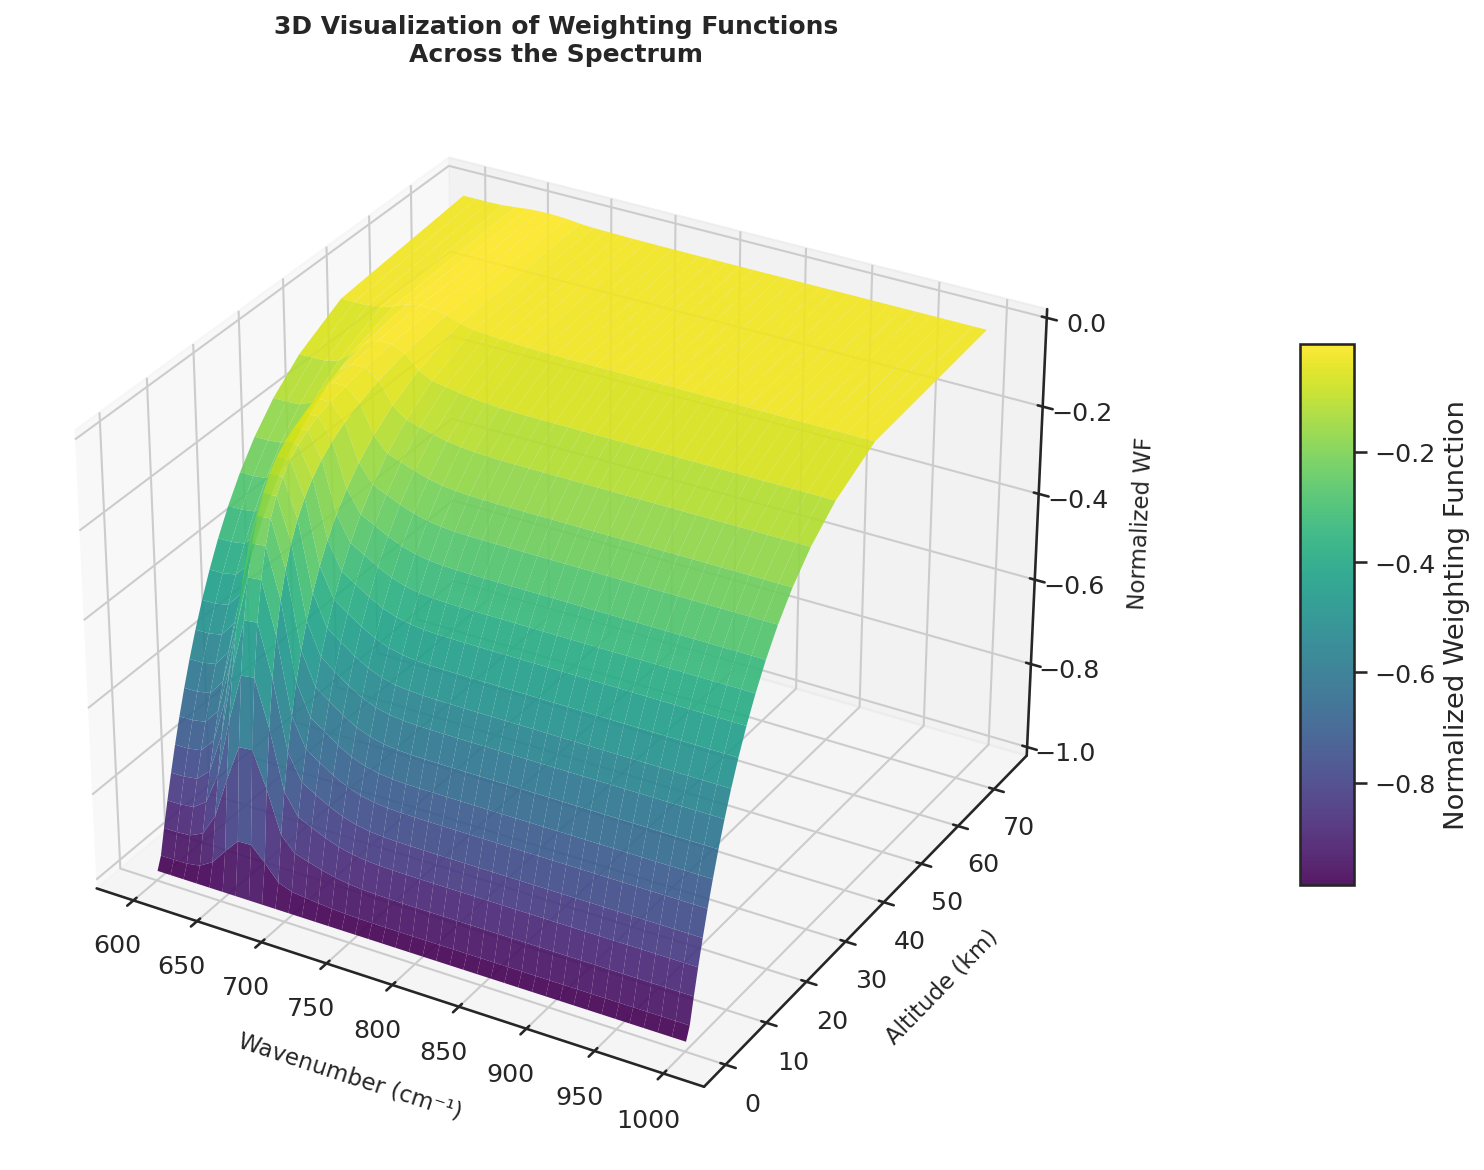

Figure 6 saved as 'Figure6_3D_WeightingFunctions.png'


In [8]:
# Cell 8: Figure 6 - 3D Surface Plot of Weighting Functions
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 8), dpi=150, facecolor='white')
fig.patch.set_facecolor('white')
ax = fig.add_subplot(111, projection='3d')

# Create data for 3D surface
wavenumbers_3d = np.linspace(600, 1000, 40)
altitudes = z_approx
WF_3d = np.zeros((len(wavenumbers_3d), len(altitudes)))

for i, nu in enumerate(wavenumbers_3d):
    # Interpolate absorption coefficient for this wavenumber
    if nu <= 700:
        k_abs = 5.0 * np.exp(-((nu - 667)**2)/(2*15**2)) + 0.05
    else:
        k_abs = 0.8 * np.exp(-((nu - 680)**2)/(2*30**2)) + 0.08
    
    k_profile = k_abs * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])
    dt_dp = np.gradient(t_profile, p_levels)
    wf = -dt_dp / np.abs(-dt_dp).max()
    WF_3d[i, :] = wf

X, Y = np.meshgrid(wavenumbers_3d, altitudes)
surf = ax.plot_surface(X, Y, WF_3d.T, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)

ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=11, labelpad=10)
ax.set_ylabel('Altitude (km)', fontsize=11, labelpad=10)
ax.set_zlabel('Normalized WF', fontsize=11, labelpad=10)
ax.set_title('3D Visualization of Weighting Functions\nAcross the Spectrum', fontsize=12, fontweight='bold')

# Add a color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label('Normalized Weighting Function')

plt.tight_layout()
plt.savefig('Figure6_3D_WeightingFunctions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 6 saved as 'Figure6_3D_WeightingFunctions.png'")

In [9]:
# Cell 9: Summary and Key Insights
print("\n" + "="*70)
print("KEY INSIGHTS FROM COMPREHENSIVE ANALYSIS:")
print("="*70)
print("\n📊 WEIGHTING FUNCTIONS:")
print("   • Window channel (900 cm⁻¹): Peaks at surface (0 km)")
print("   • CO₂ flank (680 cm⁻¹): Peaks in mid-troposphere (~5-8 km)")
print("   • CO₂ core (667 cm⁻¹): Peaks in stratosphere (~12-15 km)")

print("\n📈 CHANNEL CHARACTERISTICS:")
for idx, (ch_name, _) in enumerate(channels.items()):
    print(f"   • {ch_name}:")
    print(f"     - Peak altitude: {peak_altitudes[idx]:.1f} km")
    print(f"     - Vertical resolution: {wf_widths[idx]:.1f} km")
    sens_value = np.gradient(np.array(sensitivity[idx]), T_surface).mean()
    print(f"     - Sensitivity to surface: {sens_value:.2f} K/K")

print("\n🔬 PHYSICAL INTERPRETATION:")
print("   • Strongly absorbing channels (CO₂ core) see higher altitudes")
print("   • Weakly absorbing channels (window) see the surface")
print("   • This vertical sensitivity enables atmospheric profiling")
print("   • Understanding these relationships is crucial for:")
print("     - Satellite remote sensing")
print("     - Climate monitoring")
print("     - Weather forecasting")
print("     - Greenhouse gas retrievals")

print("\n📁 All figures have been saved as PNG files:")
print("   - Figure1_Beer_Lambert_Spectrum_Aerosols.png")
print("   - Figure2_Temperature_WeightingFunctions.png")
print("   - Figure3_BrightnessTemp_Transmittance.png")
print("   - Figure4_Sensitivity_PeakAnalysis.png")
print("   - Figure5_2D_Heatmaps.png")
print("   - Figure6_3D_WeightingFunctions.png")
print("="*70)


KEY INSIGHTS FROM COMPREHENSIVE ANALYSIS:

📊 WEIGHTING FUNCTIONS:
   • Window channel (900 cm⁻¹): Peaks at surface (0 km)
   • CO₂ flank (680 cm⁻¹): Peaks in mid-troposphere (~5-8 km)
   • CO₂ core (667 cm⁻¹): Peaks in stratosphere (~12-15 km)

📈 CHANNEL CHARACTERISTICS:
   • 900 cm⁻¹ (window):
     - Peak altitude: 73.9 km
     - Vertical resolution: 73.7 km
     - Sensitivity to surface: 0.99 K/K
   • 680 cm⁻¹ (CO₂ flank):
     - Peak altitude: 73.9 km
     - Vertical resolution: 73.7 km
     - Sensitivity to surface: 0.93 K/K
   • 667 cm⁻¹ (CO₂ core):
     - Peak altitude: 73.9 km
     - Vertical resolution: 73.7 km
     - Sensitivity to surface: 0.83 K/K

🔬 PHYSICAL INTERPRETATION:
   • Strongly absorbing channels (CO₂ core) see higher altitudes
   • Weakly absorbing channels (window) see the surface
   • This vertical sensitivity enables atmospheric profiling
   • Understanding these relationships is crucial for:
     - Satellite remote sensing
     - Climate monitoring
     - We


## Summary of Physical Principles

### 1. Radiative Transfer Equation
The fundamental equation governing satellite measurements:
$$I_\nu(\mu) = I_\nu(0) e^{-\tau_\nu/\mu} + \int_0^{\tau_\nu} B_\nu(T) e^{-(\tau_\nu - \tau_\nu')/\mu} \frac{d\tau_\nu'}{\mu}$$

### 2. Absorption Spectroscopy
Different molecules absorb at characteristic wavelengths:
- **CO₂**: Strong band at 667 cm⁻¹ (15 μm)
- **H₂O**: Rotation band at 750 cm⁻¹, vibration-rotation bands at higher wavenumbers
- **Atmospheric window**: 800-1200 cm⁻¹ (8-12 μm)

### 3. Remote Sensing Principles
- **Window channels**: See surface → used for surface temperature, clouds
- **Absorption channels**: See atmospheric layers → used for temperature profiling
- **Multiple channels**: Combined to retrieve vertical profiles

### 4. Applications
- **Weather forecasting**: Temperature and humidity profiles
- **Climate monitoring**: Long-term temperature trends
- **Greenhouse gases**: CO₂, CH₄, H₂O concentrations
- **Aerosols**: Air quality, climate forcing

---

## Key Equations Reference

| Equation | Description |
|----------|-------------|
| $T = e^{-\tau}$ | Beer-Lambert law |
| $\tau_{a}(\lambda) = \tau_{a}(\lambda_0) \cdot (\lambda/\lambda_0)^{-\alpha}$ | Ångström exponent |
| $I_{TOA} = B_s T(0) + \int B(z) \cdot \frac{dT(z)}{dz} dz$ | Radiative transfer |
| $B_\nu(T) = \frac{2h\nu^3}{c^2} \cdot \frac{1}{e^{h\nu/kT}-1}$ | Planck function |
| $W(z) = -\frac{dT(z)}{dz}$ | Weighting function |
| $T_B = \frac{h\nu/k}{\ln(1 + 2h\nu^3/(c^2 I))}$ | Brightness temperature |

---

## References and Further Reading

1. Liou, K.N. (2002). *An Introduction to Atmospheric Radiation*. Academic Press.
2. Petty, G.W. (2006). *A First Course in Atmospheric Radiation*. Sundog Publishing.
3. Stephens, G.L. (1994). *Remote Sensing of the Lower Atmosphere*. Oxford University Press.
4. Rodgers, C.D. (2000). *Inverse Methods for Atmospheric Sounding*. World Scientific.

---

## Notebook Information

- **Created**: March 2026
- **Purpose**: Educational demonstration of atmospheric radiative transfer concepts
- **Prerequisites**: Basic knowledge of atmospheric physics and radiative transfer
- **Dependencies**: numpy, matplotlib, seaborn, scipy

---

**Note**: These simulations use simplified approximations for educational purposes. Real atmospheric retrievals use more sophisticated radiative transfer models and consider multiple scattering, cloud effects, and detailed spectroscopy.
